In [1]:
# Autoreload para refletir mudanças no config sem reiniciar kernel
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import logging

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [5]:
# Célula 1.5 — garante instalação no kernel atual
import subprocess
import sys
from pathlib import Path

project_root = Path("..").resolve()

result = subprocess.run(
    ["uv", "pip", "install", "-e", str(project_root), "-q"],
    capture_output=True,
    text=True,
)
if result.returncode != 0:
    print(result.stderr)
else:
    print("churn_telecom instalado com sucesso.")

churn_telecom instalado com sucesso.


In [4]:
from churn_telecom.config import get_logger
logger = get_logger("0.03_vab_eda_bivariate")
logger.info("Iniciando análise bivariada | 0.03_vab_eda_bivariate")

Iniciando análise bivariada | 0.03_vab_eda_bivariate


In [ ]:
# Célula 3 — módulo interno do projeto
from churn_telecom.config import (
    COLS_CAT,
    COLS_NUM,
    DATA_INTERIM,
    REPORTS_FIGURES,
    CORES,
    TARGET,
)

In [ ]:
# Célula 5 — carrega dados
df = pd.read_parquet(DATA_INTERIM / "telco_typed.parquet")
logger.info("Dataset carregado. Shape: %s", df.shape)
df.head()

Dataset carregado. Shape: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [ ]:
# Célula 6 — garante que o diretório de saída existe
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

Análise bivariada avançada iniciada para 3 variáveis numéricas.
C:\Users\victo\AppData\Local\Temp\ipykernel_28312\3006399664.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series.groupby(bins)[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_28312\3006399664.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


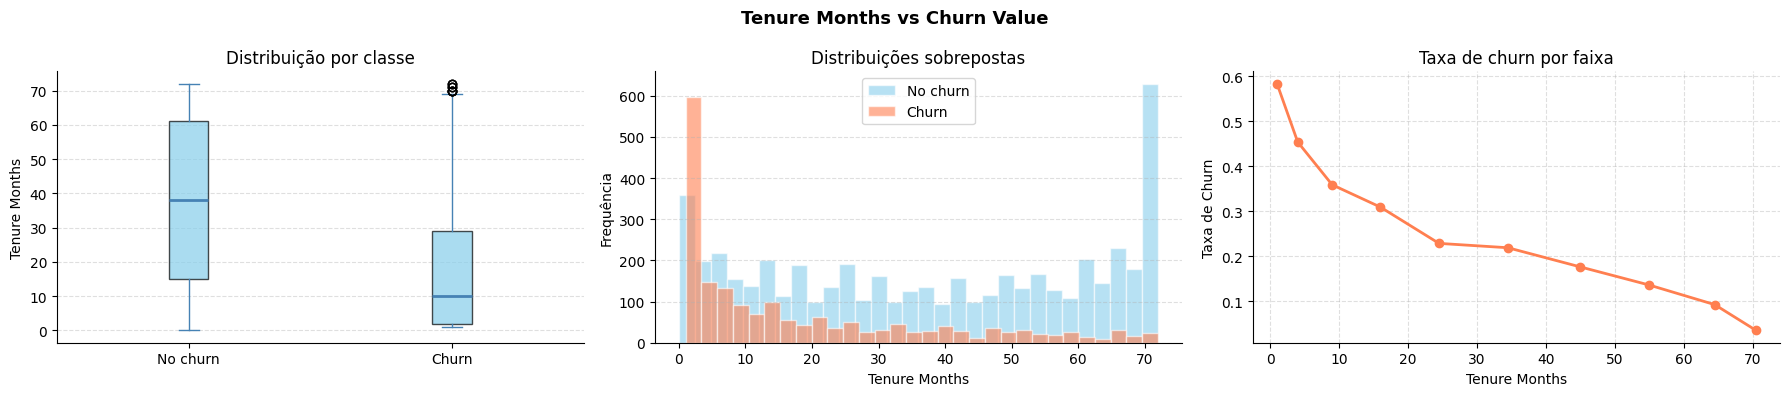

Tenure Months | n0=5174 | n1=1869 | mean_0=37.57 | mean_1=17.98 | median_0=38.00 | median_1=10.00 | std_0=24.11 | std_1=19.53 | corr=-0.3522 | cohen_d=-0.8928 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=23 (1.23%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=0 (0.00%)
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_num_tenure months.png
C:\Users\victo\AppData\Local\Temp\ipykernel_28312\3006399664.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series.groupby(bins)[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_28312\3006399664.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be d

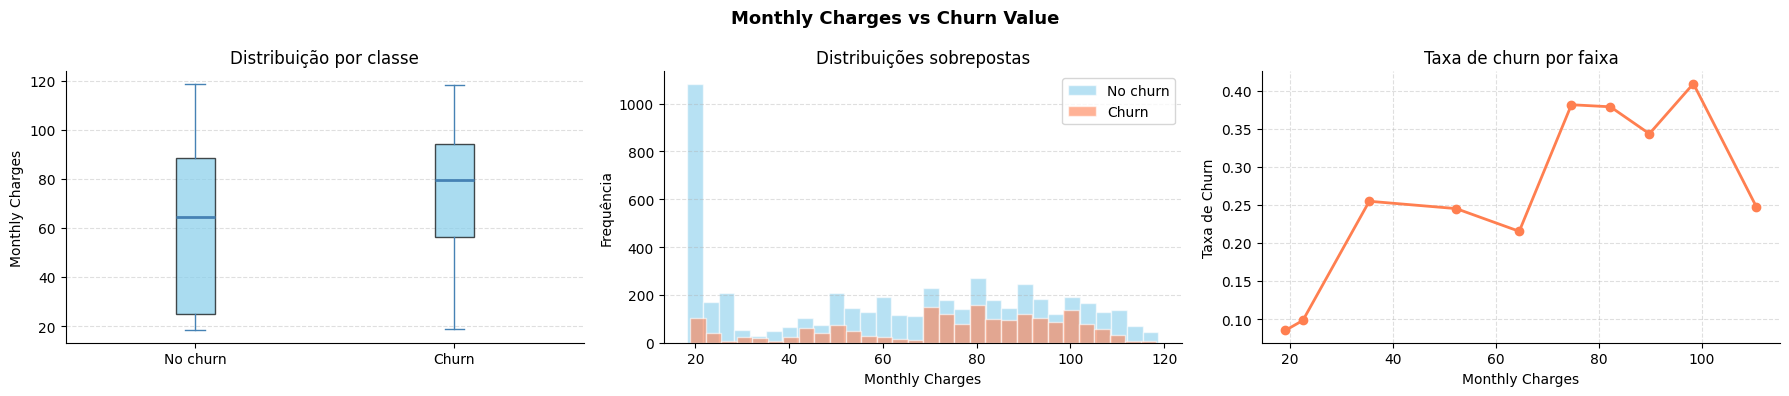

Monthly Charges | n0=5174 | n1=1869 | mean_0=61.27 | mean_1=74.44 | median_0=64.43 | median_1=79.65 | std_0=31.09 | std_1=24.67 | corr=0.1934 | cohen_d=0.4695 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=0 (0.00%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=0 (0.00%)
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_num_monthly charges.png
C:\Users\victo\AppData\Local\Temp\ipykernel_28312\3006399664.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series.groupby(bins)[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_28312\3006399664.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

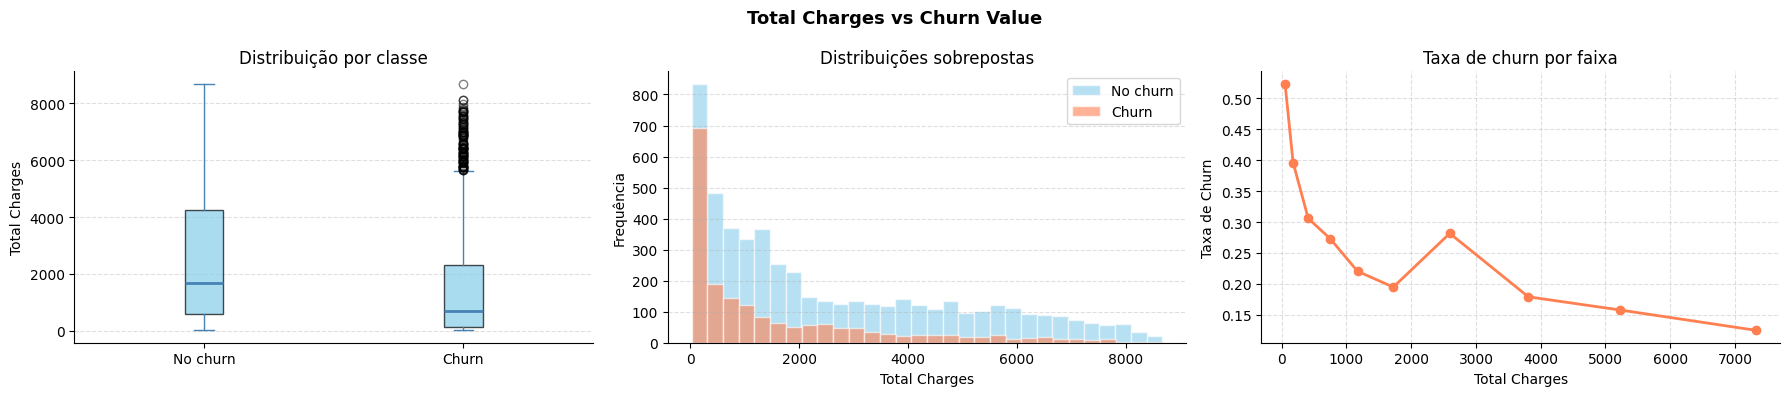

Total Charges | n0=5163 | n1=1869 | mean_0=2555.34 | mean_1=1531.80 | median_0=1683.60 | median_1=703.55 | std_0=2329.46 | std_1=1890.82 | corr=-0.1995 | cohen_d=-0.4825 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=109 (5.83%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=27 (1.44%)
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_num_total charges.png
Análise bivariada avançada finalizada.


In [ ]:
logger.info("Análise bivariada avançada iniciada para %d variáveis numéricas.", len(COLS_NUM))

from scipy import stats

for col in COLS_NUM:
    series = df[[col, TARGET]].dropna()

    grp_0 = series[series[TARGET] == 0][col]
    grp_1 = series[series[TARGET] == 1][col]

    # ── Função para outliers ─────────────────────────────────────────────
    def compute_outliers(s):
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        mask_iqr = (s < lim_inf) | (s > lim_sup)
        n_iqr = mask_iqr.sum()
        pct_iqr = n_iqr / len(s) * 100

        z_scores = np.abs(stats.zscore(s))
        mask_z = z_scores > 3
        n_z = mask_z.sum()
        pct_z = n_z / len(s) * 100

        return {
            "q1": q1, "q3": q3, "iqr": iqr,
            "lim_inf": lim_inf, "lim_sup": lim_sup,
            "n_iqr": n_iqr, "pct_iqr": pct_iqr,
            "n_z": n_z, "pct_z": pct_z
        }

    out_0 = compute_outliers(grp_0)
    out_1 = compute_outliers(grp_1)

    # ── Estatísticas ─────────────────────────────────────────────────────
    mean_0, mean_1 = grp_0.mean(), grp_1.mean()
    med_0, med_1 = grp_0.median(), grp_1.median()
    std_0, std_1 = grp_0.std(), grp_1.std()

    stat, p_value = stats.mannwhitneyu(grp_0, grp_1)

    pooled_std = np.sqrt((std_0**2 + std_1**2) / 2)
    cohen_d = (mean_1 - mean_0) / pooled_std if pooled_std != 0 else 0

    corr = series[col].corr(series[TARGET])

    # ── Curva de churn (binning) ─────────────────────────────────────────
    bins = pd.qcut(series[col], q=10, duplicates="drop")
    churn_rate = series.groupby(bins)[TARGET].mean()
    bin_centers = [interval.mid for interval in churn_rate.index]

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"{col} vs {TARGET}", fontsize=13, fontweight="bold")

    # 🔹 Boxplot
    axes[0].boxplot(
        [grp_0, grp_1],
        labels=["No churn", "Churn"],
        patch_artist=True,
        boxprops=dict(facecolor=CORES["primaria"], alpha=0.7),
        medianprops=dict(color=CORES["secundaria"], linewidth=2),
        whiskerprops=dict(color=CORES["secundaria"]),
        capprops=dict(color=CORES["secundaria"]),
        flierprops=dict(marker="o", color=CORES["alerta"], alpha=0.5),
    )
    axes[0].set_title("Distribuição por classe")
    axes[0].set_ylabel(col)
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[0].spines[["top", "right"]].set_visible(False)

    # 🔹 Histograma
    axes[1].hist(
        grp_0,
        bins=30,
        alpha=0.6,
        label="No churn",
        color=CORES["primaria"],
        edgecolor="white"
    )
    axes[1].hist(
        grp_1,
        bins=30,
        alpha=0.6,
        label="Churn",
        color=CORES["destaque"],
        edgecolor="white"
    )
    axes[1].set_title("Distribuições sobrepostas")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequência")
    axes[1].legend()
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[1].spines[["top", "right"]].set_visible(False)

    # 🔹 Linha (churn rate)
    axes[2].plot(
        bin_centers,
        churn_rate.values,
        marker='o',
        color=CORES["destaque"],
        linewidth=2
    )
    axes[2].set_title("Taxa de churn por faixa")
    axes[2].set_xlabel(col)
    axes[2].set_ylabel("Taxa de Churn")
    axes[2].grid(True, linestyle="--", alpha=0.4)
    axes[2].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    output_path = REPORTS_FIGURES / f"bivariate_num_{col.lower()}.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado ───────────────────────────────────────────────────
    logger.info(
        "%s | "
        "n0=%d | n1=%d | "
        "mean_0=%.2f | mean_1=%.2f | "
        "median_0=%.2f | median_1=%.2f | "
        "std_0=%.2f | std_1=%.2f | "
        "corr=%.4f | cohen_d=%.4f | p_value=%.6f | "
        "grp0_outliers_iqr=%d (%.2f%%) | grp1_outliers_iqr=%d (%.2f%%) | "
        "grp0_outliers_z=%d (%.2f%%) | grp1_outliers_z=%d (%.2f%%)",
        col,
        len(grp_0), len(grp_1),
        mean_0, mean_1,
        med_0, med_1,
        std_0, std_1,
        corr,
        cohen_d,
        p_value,
        out_0["n_iqr"], out_0["pct_iqr"],
        out_1["n_iqr"], out_1["pct_iqr"],
        out_0["n_z"], out_0["pct_z"],
        out_1["n_z"], out_1["pct_z"],
    )

    logger.info("Artefato salvo: %s", output_path)

logger.info("Análise bivariada avançada finalizada.")

Análise bivariada iniciada para 16 variáveis categóricas.


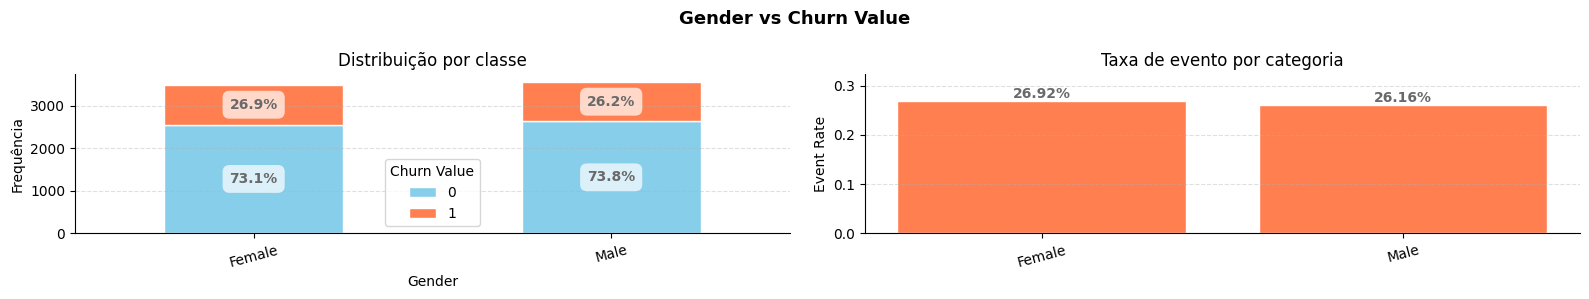

Gender | n=7043 | n_cats=2 | dominante='Male' (50.5%) | minoria='Female' (49.5%) | chi2=0.4841 | p_value=0.486579 | cramer_v=0.0083
Gender | categoria='Female' | n=3488 | n0=2549 | n1=939 | event_rate=0.2692
Gender | categoria='Male' | n=3555 | n0=2625 | n1=930 | event_rate=0.2616
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_gender.png


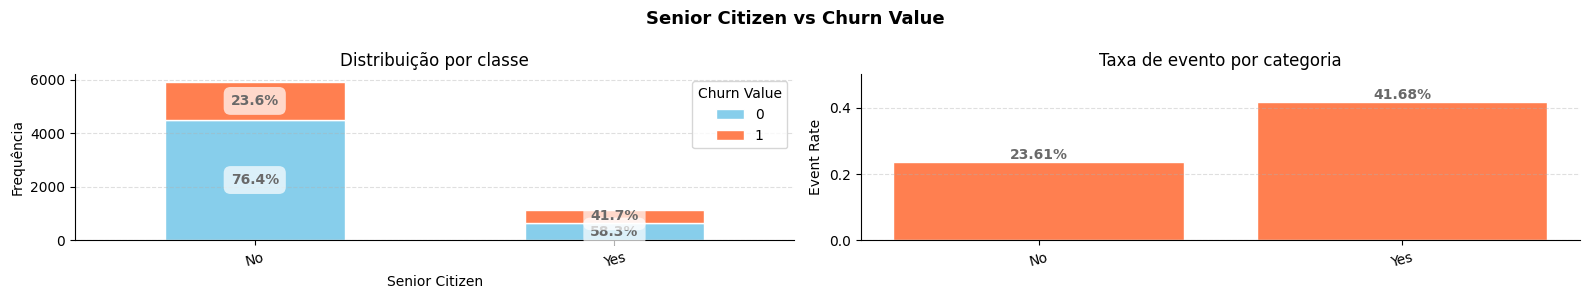

Senior Citizen | n=7043 | n_cats=2 | dominante='No' (83.8%) | minoria='Yes' (16.2%) | chi2=159.4263 | p_value=0.000000 | cramer_v=0.1505
Senior Citizen | categoria='No' | n=5901 | n0=4508 | n1=1393 | event_rate=0.2361
Senior Citizen | categoria='Yes' | n=1142 | n0=666 | n1=476 | event_rate=0.4168
Senior Citizen | alta concentração: 'No' ocupa 83.8% — avaliar poder preditivo
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_senior_citizen.png


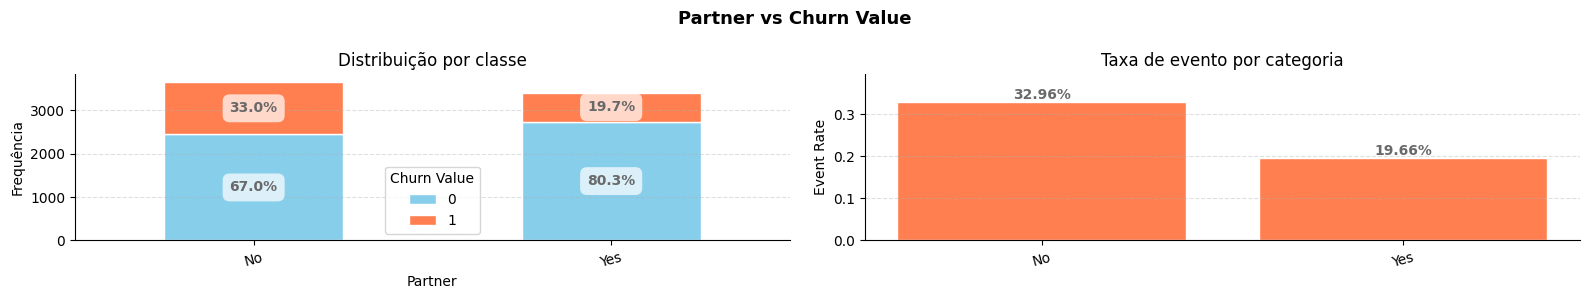

Partner | n=7043 | n_cats=2 | dominante='No' (51.7%) | minoria='Yes' (48.3%) | chi2=158.7334 | p_value=0.000000 | cramer_v=0.1501
Partner | categoria='No' | n=3641 | n0=2441 | n1=1200 | event_rate=0.3296
Partner | categoria='Yes' | n=3402 | n0=2733 | n1=669 | event_rate=0.1966
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_partner.png


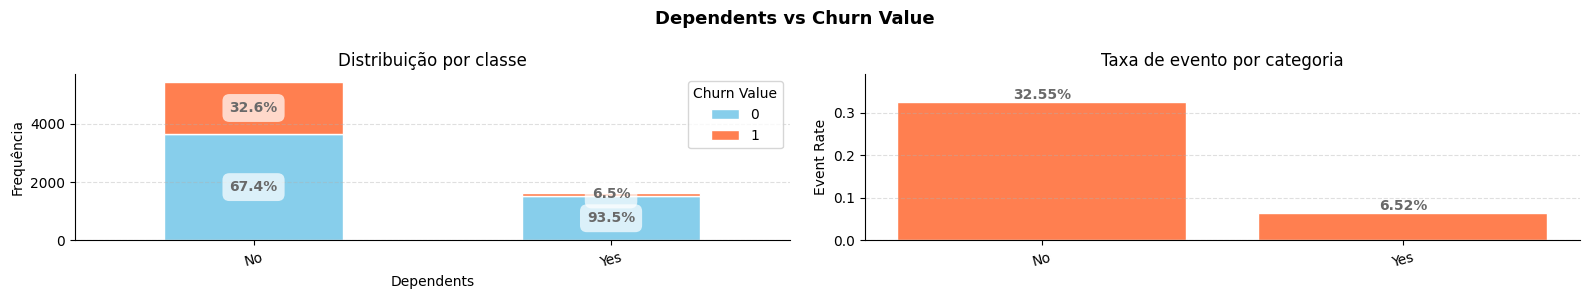

Dependents | n=7043 | n_cats=2 | dominante='No' (76.9%) | minoria='Yes' (23.1%) | chi2=433.7344 | p_value=0.000000 | cramer_v=0.2482
Dependents | categoria='No' | n=5416 | n0=3653 | n1=1763 | event_rate=0.3255
Dependents | categoria='Yes' | n=1627 | n0=1521 | n1=106 | event_rate=0.0652
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_dependents.png


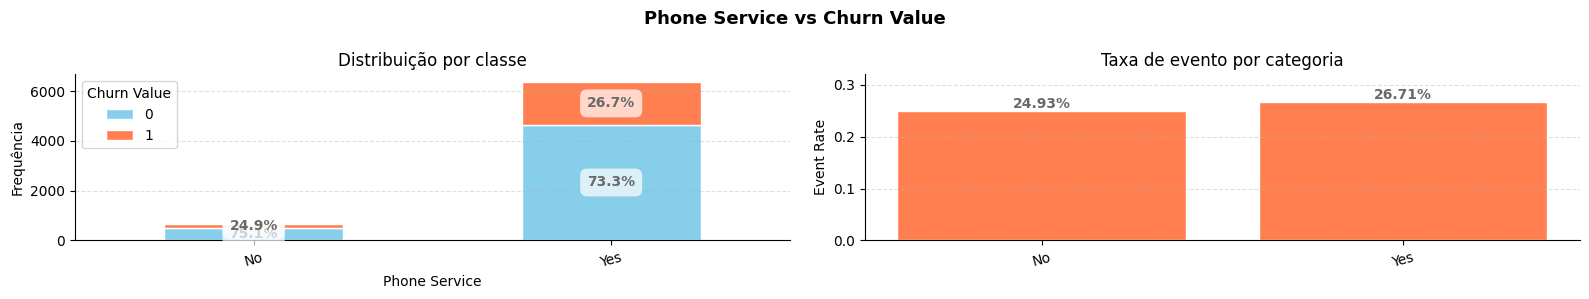

Phone Service | n=7043 | n_cats=2 | dominante='Yes' (90.3%) | minoria='No' (9.7%) | chi2=0.9150 | p_value=0.338783 | cramer_v=0.0114
Phone Service | categoria='No' | n=682 | n0=512 | n1=170 | event_rate=0.2493
Phone Service | categoria='Yes' | n=6361 | n0=4662 | n1=1699 | event_rate=0.2671
Phone Service | alta concentração: 'Yes' ocupa 90.3% — avaliar poder preditivo
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_phone_service.png


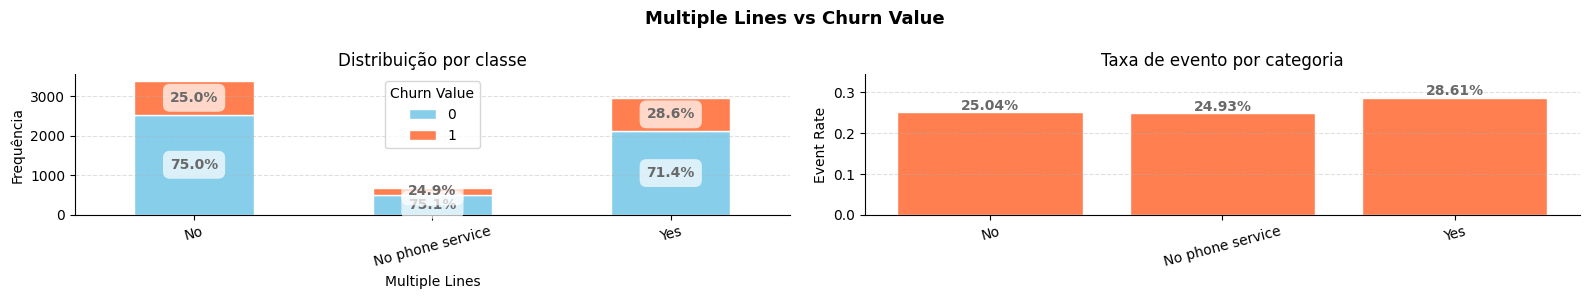

Multiple Lines | n=7043 | n_cats=3 | dominante='No' (48.1%) | minoria='No phone service' (9.7%) | chi2=11.3304 | p_value=0.003464 | cramer_v=0.0401
Multiple Lines | categoria='No' | n=3390 | n0=2541 | n1=849 | event_rate=0.2504
Multiple Lines | categoria='No phone service' | n=682 | n0=512 | n1=170 | event_rate=0.2493
Multiple Lines | categoria='Yes' | n=2971 | n0=2121 | n1=850 | event_rate=0.2861
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_multiple_lines.png


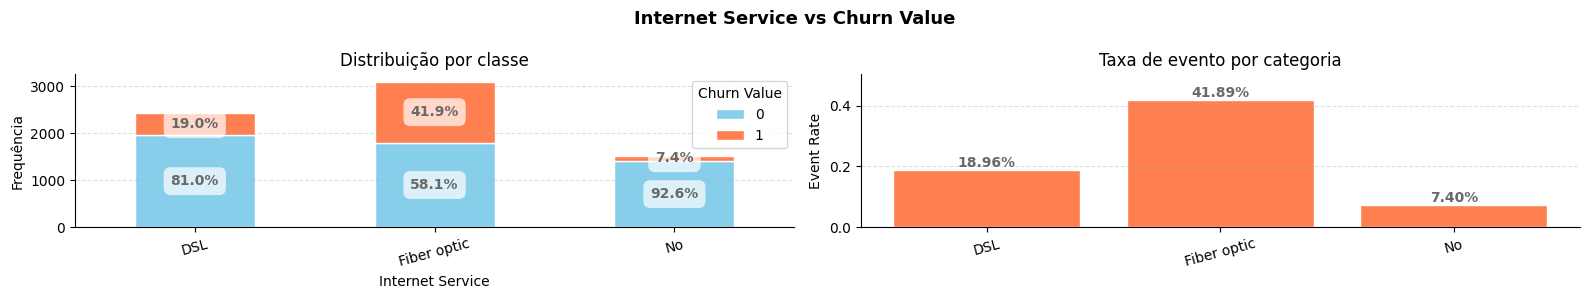

Internet Service | n=7043 | n_cats=3 | dominante='Fiber optic' (44.0%) | minoria='No' (21.7%) | chi2=732.3096 | p_value=0.000000 | cramer_v=0.3225
Internet Service | categoria='DSL' | n=2421 | n0=1962 | n1=459 | event_rate=0.1896
Internet Service | categoria='Fiber optic' | n=3096 | n0=1799 | n1=1297 | event_rate=0.4189
Internet Service | categoria='No' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_internet_service.png


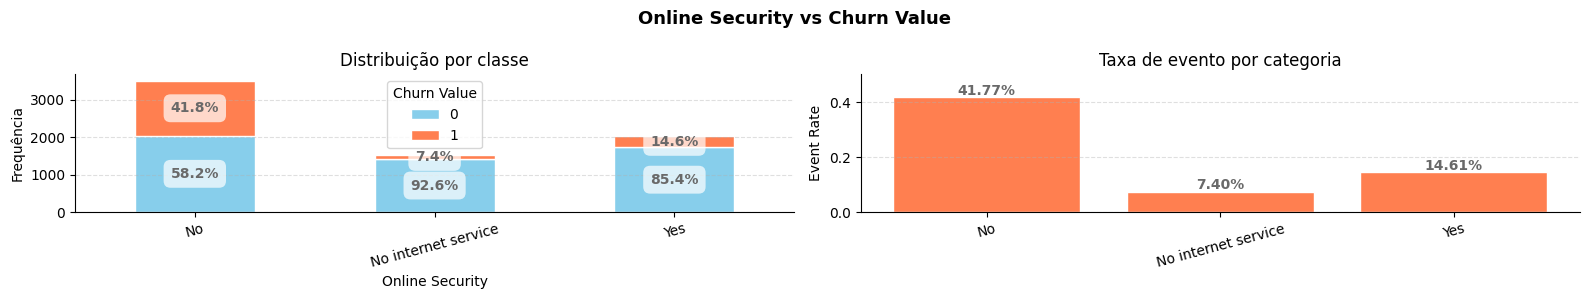

Online Security | n=7043 | n_cats=3 | dominante='No' (49.7%) | minoria='No internet service' (21.7%) | chi2=849.9990 | p_value=0.000000 | cramer_v=0.3474
Online Security | categoria='No' | n=3498 | n0=2037 | n1=1461 | event_rate=0.4177
Online Security | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
Online Security | categoria='Yes' | n=2019 | n0=1724 | n1=295 | event_rate=0.1461
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_online_security.png


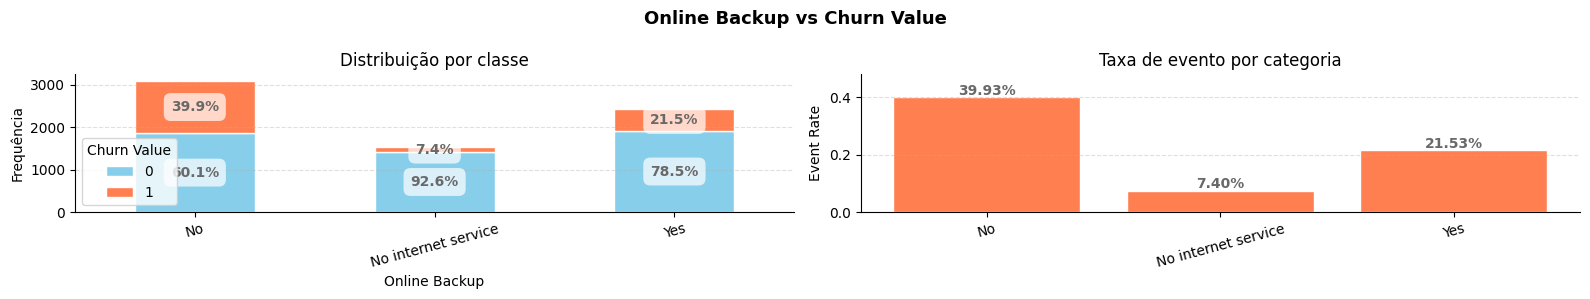

Online Backup | n=7043 | n_cats=3 | dominante='No' (43.8%) | minoria='No internet service' (21.7%) | chi2=601.8128 | p_value=0.000000 | cramer_v=0.2923
Online Backup | categoria='No' | n=3088 | n0=1855 | n1=1233 | event_rate=0.3993
Online Backup | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
Online Backup | categoria='Yes' | n=2429 | n0=1906 | n1=523 | event_rate=0.2153
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_online_backup.png


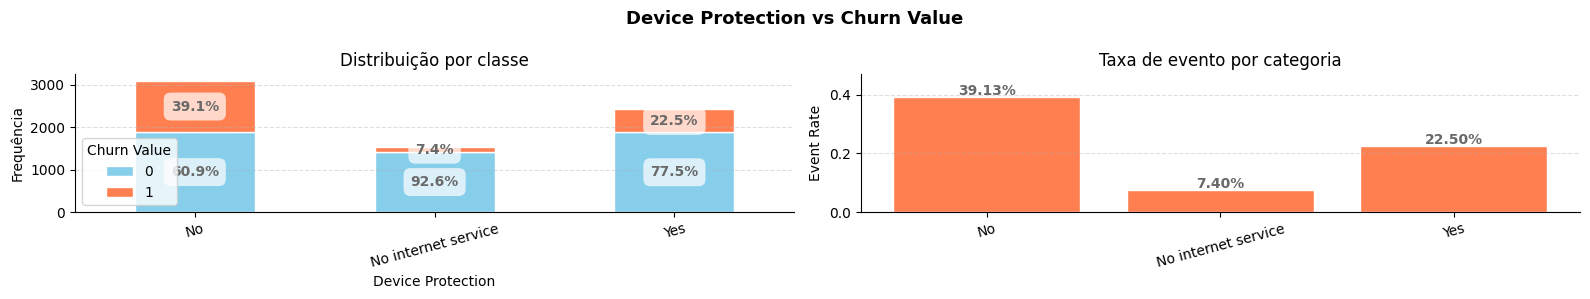

Device Protection | n=7043 | n_cats=3 | dominante='No' (43.9%) | minoria='No internet service' (21.7%) | chi2=558.4194 | p_value=0.000000 | cramer_v=0.2816
Device Protection | categoria='No' | n=3095 | n0=1884 | n1=1211 | event_rate=0.3913
Device Protection | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
Device Protection | categoria='Yes' | n=2422 | n0=1877 | n1=545 | event_rate=0.2250
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_device_protection.png


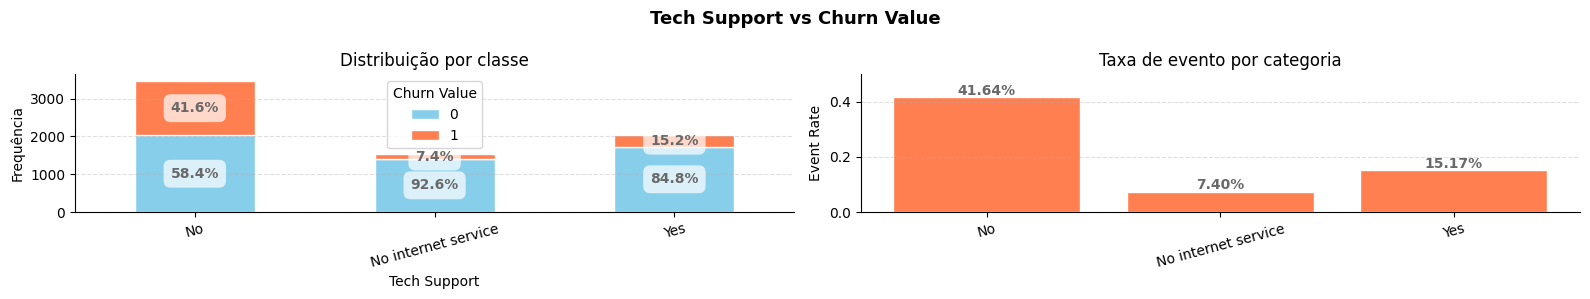

Tech Support | n=7043 | n_cats=3 | dominante='No' (49.3%) | minoria='No internet service' (21.7%) | chi2=828.1971 | p_value=0.000000 | cramer_v=0.3429
Tech Support | categoria='No' | n=3473 | n0=2027 | n1=1446 | event_rate=0.4164
Tech Support | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
Tech Support | categoria='Yes' | n=2044 | n0=1734 | n1=310 | event_rate=0.1517
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_tech_support.png


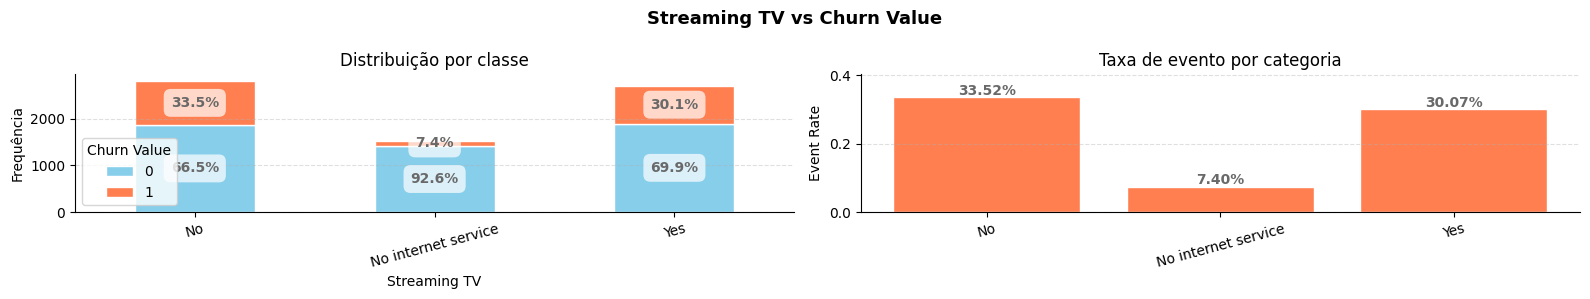

Streaming TV | n=7043 | n_cats=3 | dominante='No' (39.9%) | minoria='No internet service' (21.7%) | chi2=374.2039 | p_value=0.000000 | cramer_v=0.2305
Streaming TV | categoria='No' | n=2810 | n0=1868 | n1=942 | event_rate=0.3352
Streaming TV | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
Streaming TV | categoria='Yes' | n=2707 | n0=1893 | n1=814 | event_rate=0.3007
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_streaming_tv.png


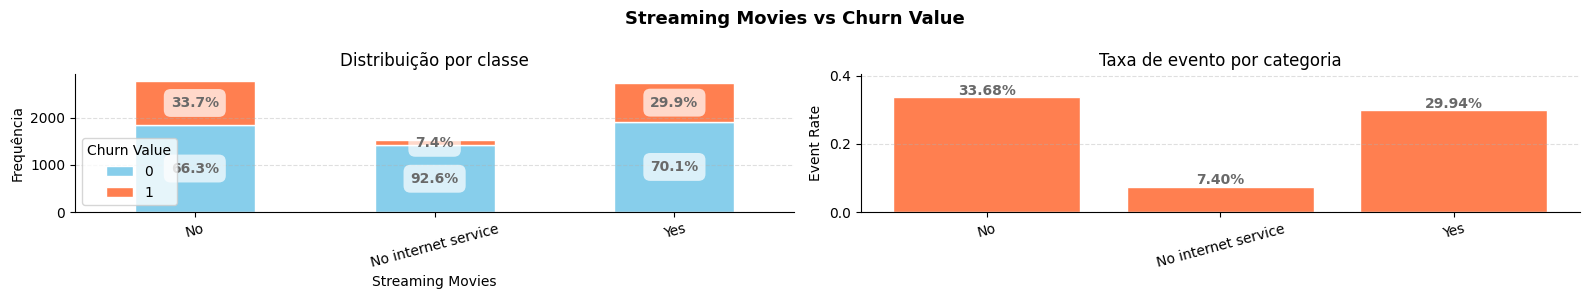

Streaming Movies | n=7043 | n_cats=3 | dominante='No' (39.5%) | minoria='No internet service' (21.7%) | chi2=375.6615 | p_value=0.000000 | cramer_v=0.2310
Streaming Movies | categoria='No' | n=2785 | n0=1847 | n1=938 | event_rate=0.3368
Streaming Movies | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
Streaming Movies | categoria='Yes' | n=2732 | n0=1914 | n1=818 | event_rate=0.2994
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_streaming_movies.png


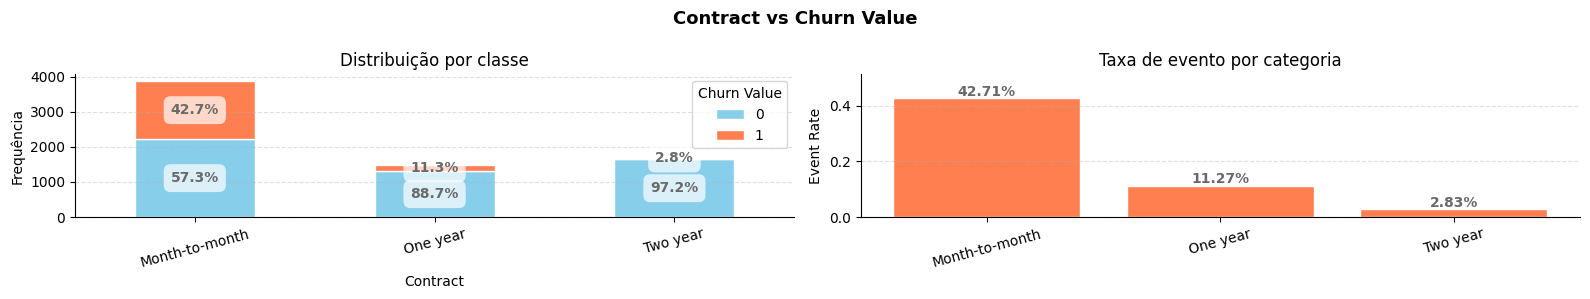

Contract | n=7043 | n_cats=3 | dominante='Month-to-month' (55.0%) | minoria='One year' (20.9%) | chi2=1184.5966 | p_value=0.000000 | cramer_v=0.4101
Contract | categoria='Month-to-month' | n=3875 | n0=2220 | n1=1655 | event_rate=0.4271
Contract | categoria='One year' | n=1473 | n0=1307 | n1=166 | event_rate=0.1127
Contract | categoria='Two year' | n=1695 | n0=1647 | n1=48 | event_rate=0.0283
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_contract.png


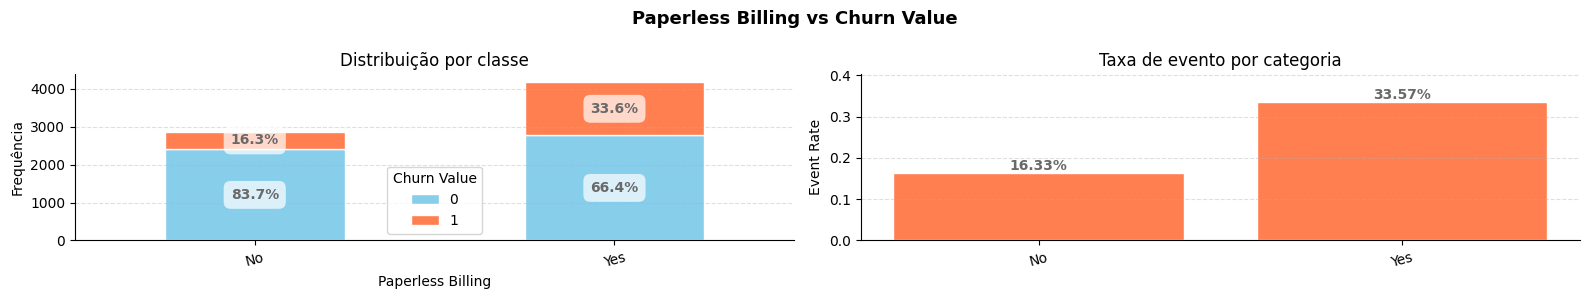

Paperless Billing | n=7043 | n_cats=2 | dominante='Yes' (59.2%) | minoria='No' (40.8%) | chi2=258.2776 | p_value=0.000000 | cramer_v=0.1915
Paperless Billing | categoria='No' | n=2872 | n0=2403 | n1=469 | event_rate=0.1633
Paperless Billing | categoria='Yes' | n=4171 | n0=2771 | n1=1400 | event_rate=0.3357
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_paperless_billing.png


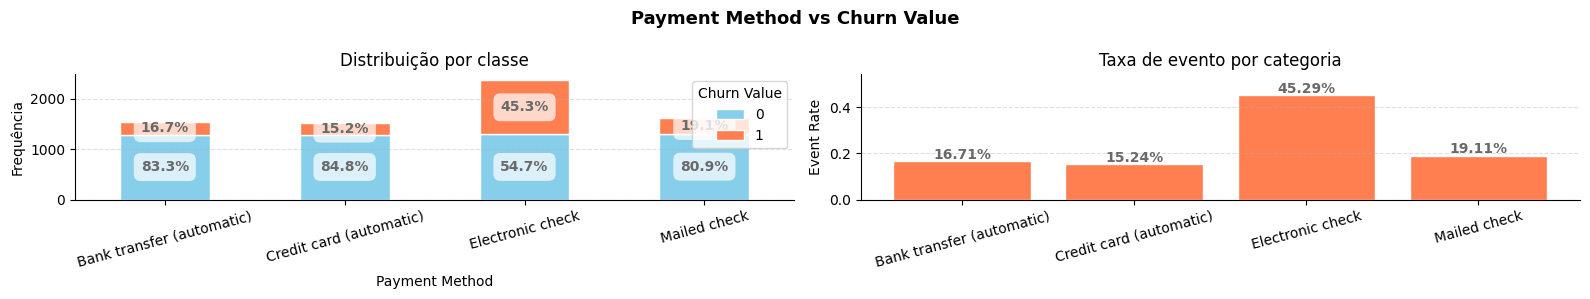

Payment Method | n=7043 | n_cats=4 | dominante='Electronic check' (33.6%) | minoria='Credit card (automatic)' (21.6%) | chi2=648.1423 | p_value=0.000000 | cramer_v=0.3034
Payment Method | categoria='Bank transfer (automatic)' | n=1544 | n0=1286 | n1=258 | event_rate=0.1671
Payment Method | categoria='Credit card (automatic)' | n=1522 | n0=1290 | n1=232 | event_rate=0.1524
Payment Method | categoria='Electronic check' | n=2365 | n0=1294 | n1=1071 | event_rate=0.4529
Payment Method | categoria='Mailed check' | n=1612 | n0=1304 | n1=308 | event_rate=0.1911
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\bivariate_cat_payment_method.png
Análise bivariada finalizada para 16 variáveis categóricas.


In [ ]:
logger.info("Análise bivariada iniciada para %d variáveis categóricas.", len(COLS_CAT))

from scipy.stats import chi2_contingency

for col in COLS_CAT:
    series = df[[col, TARGET]].dropna()

    # ── Frequência geral ────────────────────────────────────────────────
    freq_abs = series[col].value_counts()
    freq_rel = series[col].value_counts(normalize=True).mul(100).round(1)

    n_cats  = series[col].nunique()
    n_total = len(series)

    dominante = freq_abs.index[0]
    minoria   = freq_abs.index[-1]

    # ── Crosstab (base da análise bivariada) ────────────────────────────
    crosstab = pd.crosstab(series[col], series[TARGET])
  
    # Garantir colunas 0 e 1
    if 0 not in crosstab.columns:
        crosstab[0] = 0
    if 1 not in crosstab.columns:
        crosstab[1] = 0

    crosstab = crosstab[[0, 1]]

    # ── Taxa de evento (churn rate) ─────────────────────────────────────
    churn_rate = (crosstab[1] / (crosstab[0] + crosstab[1])).fillna(0)

    # ── Estatística: Chi-quadrado ───────────────────────────────────────
    chi2, p_value, _, _ = chi2_contingency(crosstab)

    # ── Cramér's V (força da associação) ────────────────────────────────
    n = crosstab.sum().sum()
    phi2 = chi2 / n
    r, k = crosstab.shape
    cramer_v = np.sqrt(phi2 / min(k - 1, r - 1)) if min(k - 1, r - 1) > 0 else 0

    # ── Categorias raras e concentração ────────────────────────────────
    cats_raras = freq_rel[freq_rel < 1.0]
    alta_concentracao = freq_rel.iloc[0] > 80.0

    # ── Plot (2 gráficos) ──────────────────────────────────────────────
    altura = max(3, n_cats * 0.6)
    fig, axes = plt.subplots(1, 2, figsize=(16, altura))
    fig.suptitle(f"{col} vs {TARGET}", fontsize=13, fontweight="bold")

    # 🔹 Distribuição absoluta (stacked)
    bars = crosstab.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        color=[CORES["primaria"], CORES["destaque"]],
        edgecolor="white"
    )

    axes[0].set_title("Distribuição por classe")
    axes[0].set_ylabel("Frequência")
    axes[0].tick_params(axis="x", rotation=15)
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[0].spines[["top", "right"]].set_visible(False)

    # ── 🔥 Anotação em % dentro das barras ─────────────────────────────
    for i, cat in enumerate(crosstab.index):
        n0 = crosstab.loc[cat, 0]
        n1 = crosstab.loc[cat, 1]
        total = n0 + n1

        pct_0 = n0 / total if total > 0 else 0
        pct_1 = n1 / total if total > 0 else 0

        # posição vertical
        y0 = n0 / 2
        y1 = n0 + (n1 / 2)

        # texto No Churn
        axes[0].text(
        i,
        y0,
        f"{pct_0:.1%}",
        ha="center",
        va="center",
        fontsize=10,
        color=CORES["neutro"],
        fontweight="bold",
        bbox=dict(
            facecolor="white",   # fundo (pode usar CORES["neutro"] com alpha)
            edgecolor="none",
            boxstyle="round,pad=0.5",  # 👈 PADDING aqui
            alpha=0.7
            )
        )

        # texto Churn
        axes[0].text(
        i,
        y1,
        f"{pct_1:.1%}",
        ha="center",
        va="center",
        fontsize=10,
        color=CORES["neutro"],
        fontweight="bold",
        bbox=dict(
            facecolor="white",   
            edgecolor="none",
            boxstyle="round,pad=0.5",  
            alpha=0.7
            )
        )

    # 🔹 Taxa de churn por categoria (ESSENCIAL)
    axes[1].bar(
        churn_rate.index,
        churn_rate.values,
        color=CORES["destaque"],
        edgecolor="white"
    )
    axes[1].set_title("Taxa de evento por categoria")
    axes[1].set_ylabel("Event Rate")
    axes[1].set_ylim(0, churn_rate.max() * 1.2)
    axes[1].tick_params(axis="x", rotation=15)
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[1].spines[["top", "right"]].set_visible(False)

    # Anotar % em cima das barras
    for i, v in enumerate(churn_rate.values):
        axes[1].text(
            i,
            v + churn_rate.max() * 0.02,
            f"{v:.2%}",
            ha="center",
            fontsize=10,
            color=CORES["neutro"],
            fontweight="bold"
        )

    plt.tight_layout()
    output_path = REPORTS_FIGURES / f"bivariate_cat_{col.lower().replace(' ', '_')}.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado ─────────────────────────────────────────────────
    logger.info(
        "%s | "
        "n=%d | n_cats=%d | "
        "dominante='%s' (%.1f%%) | minoria='%s' (%.1f%%) | "
        "chi2=%.4f | p_value=%.6f | cramer_v=%.4f",
        col,
        n_total,
        n_cats,
        dominante, freq_rel.iloc[0],
        minoria, freq_rel.iloc[-1],
        chi2,
        p_value,
        cramer_v,
    )

    # ── Log detalhado por categoria (MUITO importante) ──────────────────
    for cat in crosstab.index:
        n0 = crosstab.loc[cat, 0]
        n1 = crosstab.loc[cat, 1]
        total = n0 + n1
        rate = churn_rate.loc[cat]

        logger.info(
            "%s | categoria='%s' | n=%d | n0=%d | n1=%d | event_rate=%.4f",
            col,
            cat,
            total,
            n0,
            n1,
            rate,
        )

    # ── Alertas ─────────────────────────────────────────────────────────
    for cat, pct in cats_raras.items():
        logger.warning(
            "%s | categoria rara: '%s' = %.1f%% (%d registros)",
            col, cat, pct, freq_abs.loc[cat],
        )

    if alta_concentracao:
        logger.warning(
            "%s | alta concentração: '%s' ocupa %.1f%% — avaliar poder preditivo",
            col, dominante, freq_rel.iloc[0],
        )

    logger.info("Artefato salvo: %s", output_path)

logger.info("Análise bivariada finalizada para %d variáveis categóricas.", len(COLS_CAT))

## Análise bivariada das features

